# 2 — A guided discovery of belief geometry in transformers

**Worked solutions · draft for the Iliad Intensive**

This notebook is a **guided discovery fiction**: it reconstructs a
plausible chain of questions that could lead from optimal prediction
to the experiment in Shai et al., *Transformers Represent Belief
State Geometry in their Residual Stream*.

You will:

- turn the “same next token, different future” result into a
  hypothesis about a predictor's internal state;
- design a dataset pairing transformer activations with exact HMM
  beliefs;
- derive an affine least-squares probe;
- translate the derivation into one line of NumPy;
- predict what cross-validation, label shuffling, and training-time
  comparisons rule out;
- distinguish belief geometry from next-token geometry.

**Evidence labels matter.** The interactive plots below use a
transparent **teaching simulation, not transformer activations and
not paper data**. Reported empirical results are clearly separated
and linked to the full paper.

Five numbered **CORE** tasks plus the Mess3 simulation form a
60–70 minute notebook path, leaving room in the 90-minute block for
the introduction, transitions, and buffer. The fifth task is the
matched-next-token comparison needed to distinguish belief geometry
from optimal next-token-distribution geometry. The geometric algebra
checkpoint, paper checkpoint, one-line transcription, and final
experimental-design cards are marked **STRETCH** or **OPTIONAL**.


> <span lang="la">*longum iter est per praecepta, breve et efficax per exempla. multum interest utrum non velit an nesciat. velle non discitur.*</span>
>
> — **Seneca the Younger**, adapted from *Moral Letters to Lucilius* 6.5, 90.46, and 81.13


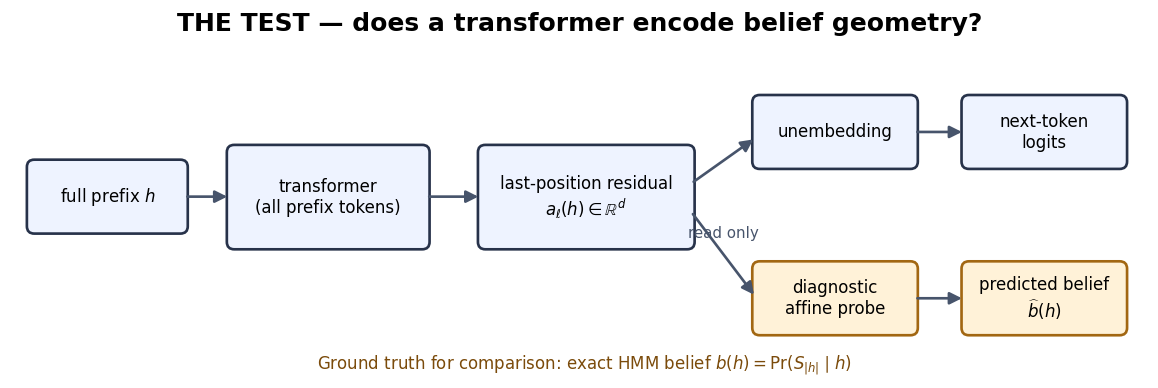

In [1]:
# ORIENTATION VISUAL — the objects used in this notebook.
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import FancyBboxPatch, FancyArrowPatch

fig, ax = plt.subplots(figsize=(12.2, 3.6))
ax.set(xlim=(0, 12.2), ylim=(0, 3.6))
ax.axis("off")

def box(x, y, w, h, text, color="#eef3ff", edge="#27324a"):
    ax.add_patch(FancyBboxPatch(
        (x, y), w, h, boxstyle="round,pad=.04,rounding_size=.08",
        fc=color, ec=edge, lw=1.6,
    ))
    ax.text(x+w/2, y+h/2, text, ha="center", va="center",
            fontsize=10)

def arrow(x1, y1, x2, y2, label=""):
    ax.add_patch(FancyArrowPatch(
        (x1, y1), (x2, y2), arrowstyle="-|>",
        mutation_scale=15, lw=1.6, color="#47546b",
    ))
    if label:
        ax.text((x1+x2)/2, (y1+y2)/2+.18, label,
                ha="center", fontsize=9, color="#47546b")

box(.2, 1.55, 1.65, .72, r"full prefix $h$")
box(2.35, 1.38, 2.1, 1.05,
    "transformer\n(all prefix tokens)")
box(5.05, 1.38, 2.25, 1.05,
    r"last-position residual"+"\n"+r"$a_\ell(h)\in\mathbb{R}^d$")
box(8.0, 2.25, 1.7, .72, "unembedding")
box(10.25, 2.25, 1.7, .72,
    "next-token\nlogits")
box(8.0, .45, 1.7, .72, "diagnostic\naffine probe",
    color="#fff2d8", edge="#a26712")
box(10.25, .45, 1.7, .72,
    r"predicted belief"+"\n"+r"$\widehat b(h)$",
    color="#fff2d8", edge="#a26712")

arrow(1.85, 1.91, 2.35, 1.91)
arrow(4.45, 1.91, 5.05, 1.91)
arrow(7.30, 2.05, 8.0, 2.55)
arrow(9.70, 2.61, 10.25, 2.61)
arrow(7.30, 1.75, 8.0, .82, "read only")
arrow(9.70, .81, 10.25, .81)

ax.text(
    6.15, .05,
    r"Ground truth for comparison: exact HMM belief "
    r"$b(h)=\Pr(S_{|h|}\mid h)$",
    ha="center", fontsize=10, color="#7b4b0b",
)
ax.set_title(
    "THE TEST — does a transformer encode belief geometry?",
    fontsize=15, fontweight="bold",
)
plt.show()


### Object and notation card

- $h=x_1\cdots x_L$: the entire token prefix presented to the model.
- $a_\ell(h)\in\mathbb R^d$: the residual-stream vector at the
  **last token position**, after layer $\ell$.
- the **unembedding** maps a final residual vector to current
  next-token logits;
- $b(h)\in\Delta^{m-1}$: the exact posterior over the $m$ hidden
  states of the chosen generator;
- a **probe** is a separate diagnostic map fit after training. It is
  not part of the transformer's forward pass.

A transformer with the full prefix can recompute information from
earlier tokens at every position. Therefore the argument below does
not force it to maintain one recursive state. Belief is one compact
sufficient representation of predictive history; whether the model
learns an affinely related representation is an empirical question.


## The discovery puzzle

A transformer is trained only to minimize next-token cross-entropy.
Why look for anything richer than its next-token probabilities?

Recall the Z1R pair from Notebook 1:

$$
\eta^{(01)}=(0,0,1),\qquad
\eta^{(10)}=(1/2,1/2,0).
$$

Both predict the next token as $(1/2,1/2)$, but their distributions
over two-token futures differ. This proves that a current
next-token vector is not, in general, a sufficient **recursive**
state. A full-prefix transformer has other options: revisit earlier
tokens, cache a richer state in activations, or use a different
predictive coordinate system. Which option training discovers is
precisely the puzzle.


## CORE 1/5 — What does the Z1R pair actually establish? (10 minutes)

1. Suppose two histories $h$ and $h'$ have identical next-token
   distributions but different distributions over complete futures.
   Argue that there must be some finite continuation $y$ after which
   their next-token distributions differ.
2. State the extra assumption needed before “therefore the model
   must distinguish them **now**” follows. Apply it to a recurrent
   predictor whose sole carried state is the next-token vector.
3. List two ways a full-context transformer could remain optimal
   without storing our HMM posterior as a persistent vector.
4. Turn the result into a cautious empirical hypothesis about
   $a_\ell(h)$ rather than a theorem about its coordinates.

<details><summary>Hint 1</summary>
If two probability distributions over infinite sequences differ,
they differ on at least one finite cylinder event (a finite prefix).
Consider the first symbol position at which the relevant conditional
probabilities diverge.
</details>

<details><summary>Hint 2</summary>
Separate “must retain enough information to distinguish predictive
futures” from “must use our preferred coordinates for that
information”.
</details>


#### Worked solution

If the full future distributions differ, there is a finite word
$yx$ whose conditional probability differs after $h$ and $h'$.
Choose a shortest such word. Their probabilities for the shorter
prefix $y$ agree up to the point where the conditional probability
of its final symbol $x$ first differs. Thus, after seeing $y$, an
optimal next-token predictor must make different predictions. If
$y$ is impossible under one history, the two predictors already
disagree at or before the first symbol that makes it impossible.

The extra assumption is that the representation being merged is the
model's **only** route by which the earlier history can affect later
predictions. A recurrent predictor that retains only its current
next-token vector satisfies this assumption: equal vectors followed
by equal inputs force identical later states, so it fails on one of
the histories.

A full-context transformer can instead attend back to distinct
prefix tokens and recompute the distinction; it could also encode a
sufficient predictive state in nonlinear or model-independent
coordinates rather than the chosen HMM's posterior.

A cautious hypothesis is therefore: predictive training may make
some layer's last-position residual $a_\ell(h)$ contain a compact
representation affinely related to the exact belief $b(h)$. That is
a testable geometric claim, not a necessity theorem.


## CORE 2/5 — Turn the idea into a testable hypothesis (8 minutes)

Imagine that we:

1. generate token histories $h_1,\ldots,h_n$ from a known HMM;
2. feed each history to a trained transformer and record one
   residual-stream activation $a(h_i)\in\mathbb R^d$;
3. calculate the exact HMM belief
   $b(h_i)\in\Delta^{m-1}\subset\mathbb R^m$.

Answer before reading on:

1. What should be the **source** and **target** of a map testing
   whether belief geometry is linearly represented?
2. Write an affine hypothesis using a matrix $W$ and offset $c$,
   including their shapes.
3. Why is predicting the belief vector a stronger geometric claim
   than classifying only the most likely hidden state?
4. Name one low error result that would nevertheless be
   unconvincing without a control.

<details><summary>Hint</summary>
The phrase “linearly represented” is operationalized as affine
decodability from activations, not as a claim that an individual
neuron equals an individual belief coordinate.
</details>


#### Worked solution

The source is the $d$-dimensional residual activation; the target is
the $m$-component ground-truth belief. With column-vector notation,

$$
b(h)\approx Wa(h)+c,\qquad
W\in\mathbb R^{m\times d},\quad c\in\mathbb R^m.
$$

A classifier need preserve only decision regions. Reconstructing the
full continuous belief vector asks it to preserve relative position,
mixtures, and the geometry inside the simplex.

Low training error alone is weak: a high-dimensional probe could
interpolate a small dataset. Other concerns include accidentally
fitting history length or token identity, choosing the projection
after seeing the target picture, or obtaining an attractive
projection even after breaking the activation–belief pairing.


## CORE 3/5 — Specify the affine belief probe (10 minutes)

Stack the activation row vectors into
$A\in\mathbb R^{n\times d}$ and beliefs into
$B\in\mathbb R^{n\times m}$. Add a column of ones:

$$
\widetilde A=
\begin{pmatrix}
--- & a(h_1)^\top & --- & 1\\
&\vdots&&\vdots\\
--- & a(h_n)^\top & --- & 1
\end{pmatrix}
\in\mathbb R^{n\times(d+1)}.
$$

1. Combine $W$ and $c$ into one parameter matrix $\Theta$. Give the
   shapes of $\widetilde A$, $\Theta$, $B$, and
   $\widehat B=\widetilde A\Theta$; check that they compose.
2. Write the least-squares objective using the Frobenius norm, and
   explain what one summand measures geometrically.
3. The minimum-norm solution is
   $\Theta^\star=\widetilde A^+B$. Explain why the pseudoinverse is
   preferable to assuming $\widetilde A^\top\widetilde A$ is
   invertible.
4. A random history split can place near-duplicate prefixes on both
   sides. Propose a held-out split that tests extrapolation across
   a meaningful history family.

<details><summary>Hint 1</summary>
With examples stored as rows, the prediction is
$\widehat B=\widetilde A\Theta$.
</details>

<details><summary>STRETCH — derive the normal equations</summary>
Differentiating
$\|\widetilde A\Theta-B\|_F^2$ gives
$2\widetilde A^\top(\widetilde A\Theta-B)$. Setting it to zero
yields
$\widetilde A^\top\widetilde A\Theta=\widetilde A^\top B$.
This derivation is optional; the geometry and experimental split
carry more weight in the timed path.
</details>


#### Worked solution

Store $W^\top$ in the first $d$ rows of $\Theta$ and $c^\top$ in its
final row, so $\Theta\in\mathbb R^{(d+1)\times m}$. Then

$$
\widehat B=\widetilde A\Theta,\qquad
\Theta^\star=\arg\min_\Theta
\|\widetilde A\Theta-B\|_F^2.
$$

One squared-error summand is the squared Euclidean displacement
between a predicted and exact belief point. The minimum-norm
least-squares solution is

$$
\Theta^\star=\widetilde A^+B.
$$

Unlike $(\widetilde A^\top\widetilde A)^{-1}\widetilde A^\top B$,
this expression remains defined when features are redundant or the
Gram matrix is singular. A stronger split can hold out whole
prefix subtrees (all histories beginning with selected two-symbol
prefixes), trajectories, or context lengths, rather than randomly
scattering neighboring histories across train and test.


### STRETCH — Undo a tilted affine embedding (5 minutes)

Suppose a three-state belief $b=(b_0,b_1,b_2)$, with
$b_0+b_1+b_2=1$, is embedded in two activation coordinates:

$$
a_1=2b_0+b_1+1,\qquad
a_2=b_0-b_1-1.
$$

Before running code, solve for $b_0,b_1,b_2$ as affine functions of
$a_1,a_2$. This confirms that an apparently tilted and translated
activation triangle can contain exactly the same belief geometry.


#### Worked solution

Adding the activation equations cancels $b_1$ and the constants:

$$
b_0=\frac{a_1+a_2}{3}.
$$

The combination $a_1-2a_2-3$ cancels $b_0$, giving

$$
b_1=\frac{a_1-2a_2-3}{3},\qquad
b_2=1-b_0-b_1.
$$

The offset is essential: a purely linear map through the origin
need not undo the translation by $(1,-1)$.


## STRETCH — Translate the formula into one line (2 minutes)

The cell supplies exact activation–belief pairs. Replace `None` with
**one NumPy expression** corresponding to your pseudoinverse formula.
This is a quick transcription check, not a programming exercise;
skip it if the matrix formula is already clear.

<details><summary>API hint</summary>
`np.linalg.pinv(M)` computes $M^+$, and matrix multiplication uses
`@`.
</details>


In [2]:
# PROVIDED SETUP — run this collapsed cell first.
import numpy as np
np.set_printoptions(precision=4, suppress=True)

B_tiny = np.array([
    [1.0, 0.0, 0.0],
    [0.0, 1.0, 0.0],
    [0.0, 0.0, 1.0],
    [1/3, 1/3, 1/3],
])
A_tiny = np.column_stack([
    2*B_tiny[:, 0] + B_tiny[:, 1] + 1,
    B_tiny[:, 0] - B_tiny[:, 1] - 1,
])
A_tiny_aug = np.column_stack([A_tiny, np.ones(len(A_tiny))])


In [3]:
# ONE-LINE STUDENT EXERCISE
theta = np.linalg.pinv(A_tiny_aug) @ B_tiny


In [4]:
# PROVIDED CHECK — run after the one-line exercise.

if theta is None:
    print("Replace `None` with the pseudoinverse expression, then rerun.")
else:
    B_tiny_hat = A_tiny_aug @ theta
    print("Theta shape:", theta.shape)
    print("maximum absolute reconstruction error:",
          np.max(np.abs(B_tiny_hat - B_tiny)))
    print("reconstructed beliefs:\n", B_tiny_hat)


Theta shape: (3, 3)
maximum absolute reconstruction error: 2.4424906541753444e-15
reconstructed beliefs:
 [[ 1.     -0.      0.    ]
 [ 0.      1.      0.    ]
 [ 0.     -0.      1.    ]
 [ 0.3333  0.3333  0.3333]]


## Predict the controls before seeing the picture

A beautiful projected fractal is memorable, but the evidential work
is done by comparisons.


### Control card — the evaluation vocabulary

| Term | Meaning here |
|---|---|
| **fit / training set** | histories whose activation–belief pairs choose the probe parameters $\Theta$ |
| **evaluation / held-out set** | histories not used to choose $\Theta$; these test whether the same map generalizes |
| **mean squared error (MSE)** | average squared coordinate error, $\frac{1}{nm}\sum_{i,j}(\widehat B_{ij}-B_{ij})^2$; lower is better |
| **baseline** | a competing predictor using less or different information |
| **negative control** | a deliberately broken relationship, such as shuffled activation–belief pairings, that should fail |
| **checkpoint** | the same model architecture saved at a particular stage of training |

A probe with tiny fit error but large held-out error has memorized or
interpolated the fit set. If shuffled pairings also achieved low
held-out MSE, low error for the real pairing would not be convincing.
None of these observations alone shows that the model **uses** the
decoded direction: decodability is correlational; causal use requires
a targeted intervention and a predicted downstream effect.


## CORE 4/5 — What does each comparison rule out? (10 minutes)

For each comparison, predict the result under a genuine
activation-to-belief relationship and state the main alternative it
addresses.

1. Fit on complete two-symbol prefix subtrees and evaluate on other
   subtrees, so no held-out history has a near-duplicate ancestor in
   the training set.
2. Randomly permute belief labels across activations before fitting,
   while preserving the set of target belief points.
3. Repeat the analysis at checkpoints from initialization through
   the end of training.
4. Compare the activation probe with four baselines: mean belief,
   last-token-plus-length, exact next-token probabilities, and
   shuffled belief labels.
Which of these controls provides causal evidence that the transformer
**uses** the decoded beliefs? If none does, propose the kind of
intervention that would.

<details><summary>Hint</summary>
Separate “generalizes to unseen examples”, “not an arbitrary
high-to-low-dimensional projection”, “emerges with learning”, and
“contains more than optimal next-token probabilities”.
</details>


#### Worked solution

1. Low subtree-held-out MSE shows that the map generalizes across a
   structured change in prefixes, not merely between interleaved,
   neighboring histories.
2. After shuffling, the target fractal still exists as a set, but its
   pointwise correspondence with activations is broken. Failure
   rules out the story that an arbitrary linear projection can be
   chosen to paint any desired geometry.
3. Improvement through training links decodability to learned
   predictive competence rather than initialization or architecture
   alone.
4. Beating the mean rules out trivial concentration near the
   stationary belief. Beating token/length features rules out
   obvious prefix covariates. Beating a next-token-only map asks
   whether the probe contains predictive distinctions beyond the
   optimal next-token distribution. Shuffling tests whether arbitrary
   high-dimensional projections can paint the target set.

These are correlational and geometric controls. They do not show
causal use. A causal test could perturb an activation specifically
along a decoded belief direction, predict the resulting Bayesian
change in later-token probabilities or later activations, and compare
it with matched orthogonal and random-direction interventions.


## CORE VISUAL — Watch a belief signal become recoverable (10 minutes)

The next cell constructs exact beliefs for the **pedagogical
Mess3-family parameter variant used in Notebook 1**
($x=.15,a=.20$), embeds them into a 24-dimensional synthetic
“activation” with a random affine map, and adds nuisance variation.
The paper uses a different Mess3 parameterization
($x=.05,a=.85$). Across four mock checkpoints, the
signal-to-noise ratio rises. The probe trains on all histories in
three two-symbol prefix subtrees and tests on the other six; it is
also compared with simple covariate and next-token baselines.

**This is a teaching simulation, not transformer activations, not
paper data, and not the paper's generator parameters.** Its purpose
is to make the regression and controls inspectable without asking
you to train a model.

Before running it, sketch:

- the held-out MSE curve you expect;
- what the earliest and latest recovered geometry should look like;
- what a shuffled-label projection should do;
- whether Mess3's exact next-token probabilities might already
  reveal much of its belief.


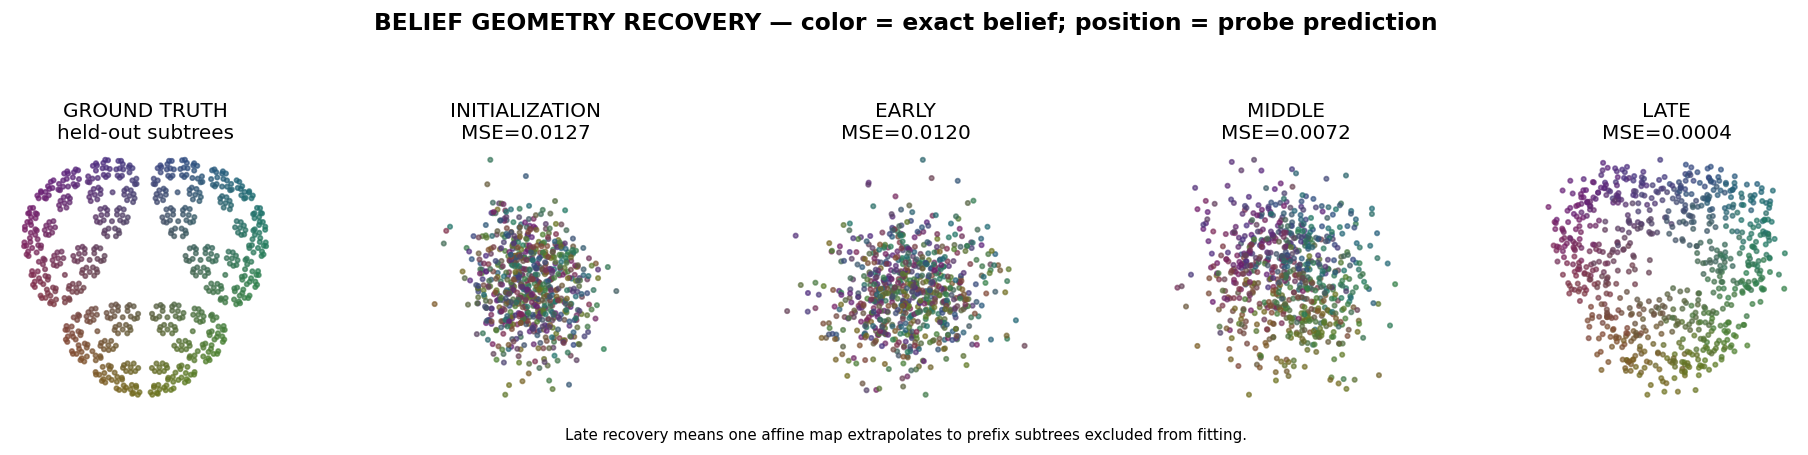

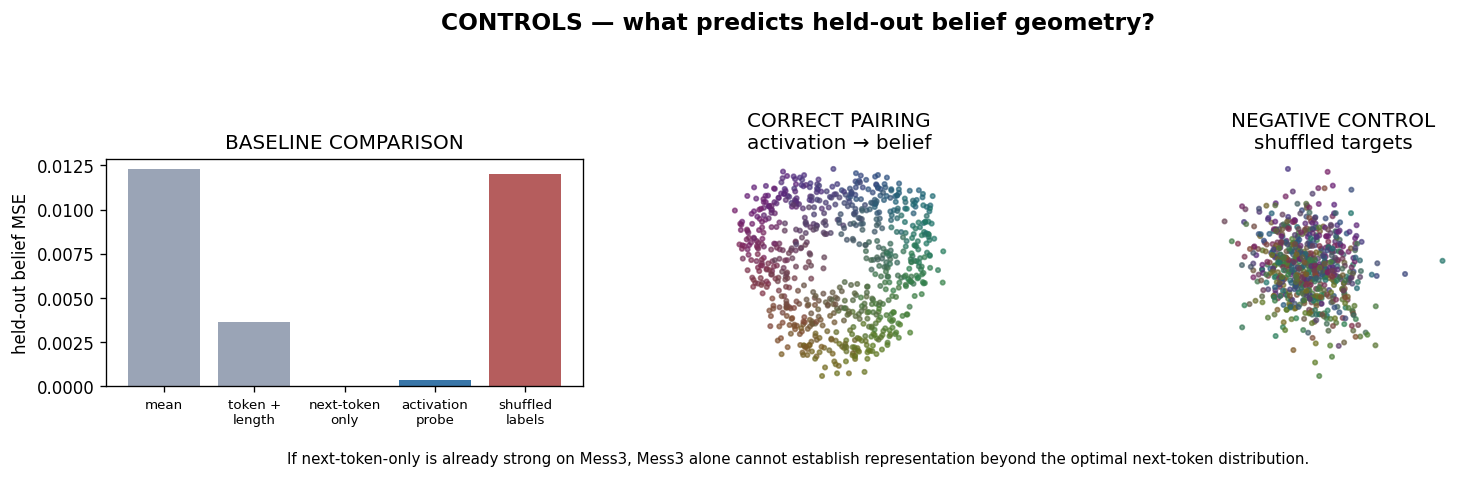

Training subtrees: [(0, 0), (1, 1), (2, 2)]
Held-out subtree fraction: 0.6666666666666666
mean MSE: 0.01226703066133584
token + length MSE: 0.003614211918234973
next-token only MSE: 3.0929228768914037e-30
activation probe MSE: 0.0003594441620498218
shuffled labels MSE: 0.012034386105689169


In [5]:
# TEACHING SIMULATION — supplied analysis and visualization.
import itertools
import matplotlib.pyplot as plt

simplex_vertices = np.array([
    [0.0, 0.0],
    [1.0, 0.0],
    [0.5, np.sqrt(3) / 2],
])

def mess3(x=0.15, a=0.2):
    b = (1 - a) / 2
    y = 1 - 2*x
    ay, bx, by, ax = a*y, b*x, b*y, a*x
    return np.array([
        [[ay,bx,bx], [ax,by,bx], [ax,bx,by]],
        [[by,ax,bx], [bx,ay,bx], [bx,ax,by]],
        [[by,bx,ax], [bx,by,ax], [bx,bx,ay]],
    ])

def exact_belief(word, tensor, initial):
    v = initial.copy()
    for x in word:
        v = v @ tensor[x]
    return v / v.sum()

mess_T = mess3()
initial = np.ones(3) / 3
histories = [
    word
    for depth in range(2, 7)
    for word in itertools.product(range(3), repeat=depth)
]
B = np.array([exact_belief(w, mess_T, initial) for w in histories])

rng = np.random.default_rng(12)
n, d = len(B), 24
embedding = rng.normal(size=(3, d))
offset = rng.normal(scale=.4, size=d)
nuisance = rng.normal(size=(n, d))

# A structured split: whole first-two-symbol subtrees are held out.
train_subtrees = {(0, 0), (1, 1), (2, 2)}
train = np.array([
    i for i, word in enumerate(histories)
    if tuple(word[:2]) in train_subtrees
])
test = np.array([
    i for i, word in enumerate(histories)
    if tuple(word[:2]) not in train_subtrees
])

def augment(A):
    return np.column_stack([A, np.ones(len(A))])

def fit_probe(A, targets):
    return np.linalg.pinv(augment(A)) @ targets

def apply_probe(A, theta):
    return augment(A) @ theta

levels = [
    ("initialization", 0.00),
    ("early", 0.05),
    ("middle", 0.18),
    ("late", 1.20),
]
predictions = []
mses = []
activations = []
for name, signal_strength in levels:
    A = offset + signal_strength*(B @ embedding) + .12*nuisance
    theta_level = fit_probe(A[train], B[train])
    B_hat = apply_probe(A[test], theta_level)
    activations.append(A)
    predictions.append(B_hat)
    mses.append(np.mean((B_hat - B[test])**2))

fig, axes = plt.subplots(1, len(levels) + 1, figsize=(16, 3.7))
true_xy = B[test] @ simplex_vertices
axes[0].scatter(true_xy[:, 0], true_xy[:, 1],
                c=np.clip(B[test], 0, 1), s=7, alpha=.7)
axes[0].set_title("GROUND TRUTH\nheld-out subtrees")
for ax, (name, _), B_hat in zip(axes[1:], levels, predictions):
    recovered_xy = B_hat @ simplex_vertices
    ax.scatter(recovered_xy[:, 0], recovered_xy[:, 1],
               c=np.clip(B[test], 0, 1), s=7, alpha=.65)
    ax.set_title(
        f"{name.upper()}\nMSE={np.mean((B_hat-B[test])**2):.4f}"
    )
for ax in axes:
    ax.set_aspect("equal")
    ax.axis("off")
fig.suptitle(
    "BELIEF GEOMETRY RECOVERY — color = exact belief; "
    "position = probe prediction",
    fontsize=14, fontweight="bold",
)
fig.text(
    .5, .015,
    "Late recovery means one affine map extrapolates to prefix "
    "subtrees excluded from fitting.",
    ha="center", fontsize=9,
)
plt.tight_layout(rect=(0, .05, 1, .91))
plt.show()

final_A = activations[-1]

# Baselines are fit on exactly the same histories.
mean_hat = np.tile(B[train].mean(axis=0), (len(test), 1))

history_features = np.zeros((n, 4))
for i, word in enumerate(histories):
    history_features[i, word[-1]] = 1
    history_features[i, 3] = len(word) / 6
covariate_theta = fit_probe(history_features[train], B[train])
covariate_hat = apply_probe(
    history_features[test], covariate_theta
)

emission_map = np.stack([
    mess_T[symbol].sum(axis=1) for symbol in range(3)
], axis=1)
next_token = B @ emission_map
next_theta = fit_probe(next_token[train], B[train])
next_hat = apply_probe(next_token[test], next_theta)

shuffled_B = B[rng.permutation(n)]
shuffled_theta = fit_probe(final_A[train], shuffled_B[train])
shuffled_hat = apply_probe(final_A[test], shuffled_theta)

baseline_names = [
    "mean",
    "token +\nlength",
    "next-token\nonly",
    "activation\nprobe",
    "shuffled\nlabels",
]
baseline_mses = [
    np.mean((mean_hat - B[test])**2),
    np.mean((covariate_hat - B[test])**2),
    np.mean((next_hat - B[test])**2),
    mses[-1],
    np.mean((shuffled_hat - B[test])**2),
]

fig, axes = plt.subplots(1, 3, figsize=(13.2, 3.9))
axes[0].bar(
    np.arange(len(baseline_mses)), baseline_mses,
    color=["#9aa4b6", "#9aa4b6", "#d39a3a", "#3976a8", "#b55d5d"],
)
axes[0].set(
    xticks=np.arange(len(baseline_names)),
    xticklabels=baseline_names,
    ylabel="held-out belief MSE",
    title="BASELINE COMPARISON",
)
axes[0].tick_params(axis="x", labelsize=8)
late_xy = predictions[-1] @ simplex_vertices
axes[1].scatter(late_xy[:, 0], late_xy[:, 1],
                c=np.clip(B[test], 0, 1), s=7, alpha=.65)
axes[1].set_title("CORRECT PAIRING\nactivation → belief")

shuffled_xy = shuffled_hat @ simplex_vertices
axes[2].scatter(shuffled_xy[:, 0], shuffled_xy[:, 1],
                c=np.clip(B[test], 0, 1), s=7, alpha=.65)
axes[2].set_title("NEGATIVE CONTROL\nshuffled targets")
for ax in axes[1:]:
    ax.set_aspect("equal")
    ax.axis("off")
fig.suptitle(
    "CONTROLS — what predicts held-out belief geometry?",
    fontsize=14, fontweight="bold",
)
fig.text(
    .5, .015,
    "If next-token-only is already strong on Mess3, Mess3 alone "
    "cannot establish representation beyond the optimal "
    "next-token distribution.",
    ha="center", fontsize=9,
)
plt.tight_layout(rect=(0, .06, 1, .90))
plt.show()

print("Training subtrees:", sorted(train_subtrees))
print("Held-out subtree fraction:", len(test) / n)
for name, value in zip(baseline_names, baseline_mses):
    print(name.replace("\n", " "), "MSE:", value)


### Interpret, do not merely admire

Compare your predictions with the plots.

1. Why are the recovered points allowed to fall slightly outside the
   simplex?
2. Why color recovered points by their **ground-truth** beliefs
   rather than by their recovered coordinates?
3. Why is a held-out prefix-subtree split more informative than a
   random point split here?
4. If the next-token-only baseline nearly matches the activation
   probe on Mess3, what experiment should become central next?
5. What aspect of the simulation is deliberately unrealistic?
6. What would you want to inspect before trusting the same pipeline
   on real transformer activations?


#### Worked solution

An unconstrained affine regression does not enforce nonnegativity or
sum-to-one, so noise can place predictions outside the simplex.
Ground-truth colors preserve point identity: nearby colors in the
recovered plot mean that nearby true beliefs remain nearby after
projection. Coloring by the predictions themselves could make a
distorted result look smooth by construction.

Holding out whole subtrees prevents closely related continuations
from straddling the split and asks the affine map to extrapolate
across a meaningful context family. If next-token probabilities
already decode Mess3 belief, the central test should use histories
or a process deliberately matched on optimal next-token
distributions but separated on longer futures.

The simulation explicitly plants a linear belief signal and merely
changes its signal-to-noise ratio; a real network is not handed this
embedding. On real activations we would inspect held-out errors,
split construction, layer and position choices, baselines, shuffled
correspondences, dependence on probe regularization, and whether
simpler covariates such as token, position, or model next-token probabilities
explain the result.


## OPTIONAL PAPER CHECKPOINT — What Shai et al. report (8 minutes)

Full source: [Shai et al., *Transformers Represent Belief State
Geometry in their Residual Stream* (NeurIPS 2024,
arXiv:2405.15943)](https://arxiv.org/abs/2405.15943).

For Mess3, the authors:

- calculate the exact belief associated with each input history;
- record 64-dimensional final residual-stream activations;
- fit an affine map from activations to the three-state belief;
- recover the fractal belief geometry;
- show decreasing regression MSE over training;
- obtain similar held-out performance under **random
  input–activation-pair splits**, fitting on 20% and evaluating on
  80%, repeated independently 1,000 times—not the structured
  prefix-subtree split used in the teaching simulation above;
- find that shuffling activation–belief correspondences collapses
  the recovered structure toward the simplex center.

See the paper's [method schematic and main
result](https://arxiv.org/html/2405.15943#S2.SS3) and
[Figure 6 controls](https://arxiv.org/html/2405.15943#S3.F6).

These results support affine decodability and geometric
correspondence. They do not, on their own, prove that the decoded
coordinates are causally used.


## CORE 5/5 — Matched next-token histories (10 minutes)

The paper also studies Random–Random–XOR (RRXOR), whose 36 belief
states include many pairs with the same next-token prediction.

Z1R already supplied the logic: histories `01` and `10` have equal
current next-token vectors, while test `00` separates their longer
futures. A representation that separates such matched pairs cannot
be explained by optimal next-token distributions alone. RRXOR scales
that diagnostic idea to a richer finite belief set.

Before reading the result:

1. If final-layer activations feed directly into an unembedding for
   the current next token, where would you expect distinctions
   irrelevant to the predicted next-token distribution to become
   weaker?
2. Why might concatenating activations from all layers reveal a
   representation not linearly decodable from any one layer?
3. Design a distance comparison that separates “activation geometry
   tracks beliefs” from “activation geometry tracks only next-token
   probabilities”.


#### Worked solution

Predictive directions irrelevant to the current next-token
distribution can be compressed as computation approaches the final
unembedding, so final-layer decodability may be weaker than
intermediate or distributed decodability.

Different layers may each carry different linear views or fragments
of the relevant state. Concatenation lets one linear map combine
these coordinates, though this observation alone does not specify
the transformer's causal algorithm.

For pairs of histories, compute:

- distance between their exact belief vectors;
- distance between their decoded activation representations;
- distance between their next-token distributions.

If decoded-activation distances follow belief distances even among
pairs whose next-token-probability distance is zero or small, optimal
next-token distributions cannot explain the geometry. RRXOR was
chosen to make this comparison diagnostic.


### Reveal — reported RRXOR result

RRXOR belief geometry is poorly decoded from the final layer and
from individual layers, but is recovered from concatenated
activations across layers. Pairwise distances in the recovered
representation track ground-truth belief distances ($R^2=0.95$);
their relation to distances between ground-truth optimal next-token
probability distributions is much weaker ($R^2=0.31$).

This is the core contrast that Mess3 alone cannot supply: the
representation separates predictive states even where current
next-token probabilities are matched.


## STRETCH DESIGN STUDIO — choose one experiment card

Choose **one** card rather than inventing every component at once:

- **Matched-prediction process:** construct many history pairs with
  identical optimal next-token distributions and separated two- or
  three-step tests.
- **Belief-direction intervention:** perturb an activation along a
  decoded belief direction and compare later logits with the HMM's
  quantitative prediction.
- **Objective comparison:** train matched architectures under
  objectives that differ in how much longer-future information is
  useful.

Fill one row:

| Field | Your design |
|---|---|
| diagnostic process / contrast | |
| activation source and target | |
| negative control or baseline | |
| numerical success criterion | |
| outcome that weakens the hypothesis | |

If time remains, exchange rows with another group and identify one
confound their proposed control does not address.


#### Worked solution

One example:

- **Process:** use a small HMM with many history pairs matched on
  next-token probabilities but separated on two- and three-token
  tests.
- **Measurements:** decode beliefs and next-token vectors from every
  layer and position using strictly held-out histories.
- **Controls:** shuffled targets, matched random directions,
  position/token baselines, and a model trained on permuted data
  that preserves unigram statistics but destroys the long-range
  process.
- **Intervention:** move an activation a controlled distance along a
  decoded belief difference while holding the decoded next-token
  vector approximately fixed; predict the later conditional logits
  from the HMM update.
- **Criterion:** later logits and later decoded beliefs change in
  the predicted direction more than under matched controls.
- **Falsifier:** high observational decodability but no selective,
  predicted downstream effect under intervention would weaken the
  claim that the affine belief coordinates are causally used.


### Exit ticket

Complete both clauses:

> The affine probe is interesting because ________.  
> The affine probe is not yet decisive because ________.
